<a href="https://colab.research.google.com/github/sundaybest3/txtanalysis/blob/function_position/position_frequency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd

# CSV 파일 읽기
filename = '/content/sample_data/High School Textbook Dialogue data_first analysis.csv'
# 'euc-kr' 인코딩을 사용하여 파일 읽기 시도
df_textbook = pd.read_csv(filename, encoding='euc-kr') # Renamed df to df_textbook to avoid conflict

# Position 열 확인
print(df_textbook.columns)

# 'Position_B' 컬럼의 공백 제거 및 빈도표 생성
df_textbook['Position_B'] = df_textbook['Position_B'].str.strip()
position_counts_textbook = df_textbook['Position_B'].value_counts().sort_index()

print(position_counts_textbook)

textbook_position_data = position_counts_textbook.reset_index()
textbook_position_data.columns = ['Position', 'Frequency']

# 백분율 계산 및 추가
total_count_textbook = textbook_position_data['Frequency'].sum()
textbook_position_data['Percentage'] = (textbook_position_data['Frequency'] / total_count_textbook * 100).round(2)

print(textbook_position_data)


Index(['Publisher', 'Author', 'Grade Level', 'Lesson No.', 'Section Title',
       'Subsection', 'Label', 'Conversation ID', 'Speech type', 'Turn No.',
       'Speaker', 'Script', 'Word Count', 'Position_A', 'Function_A',
       'Position_B', 'Function_B', 'Consistency', 'Agreement'],
      dtype='object')
Position_B
TI     10
UI    135
UM     10
Name: count, dtype: int64
  Position  Frequency  Percentage
0       TI         10        6.45
1       UI        135       87.10
2       UM         10        6.45


In [34]:
# CSV 파일 읽기
filename = '/content/sample_data/High School Textbook Dialogue data_first analysis.csv'
# 'euc-kr' 인코딩을 사용하여 파일 읽기 시도
df = pd.read_csv(filename, encoding='euc-kr')

# Position 열 확인
print(df.columns)

# 'Position_B' 컬럼의 공백 제거 및 빈도표 생성
df['Position_B'] = df['Position_B'].str.strip()
position_counts = df['Position_B'].value_counts().sort_index()

print(position_counts)

position_table = position_counts.reset_index()
position_table.columns = ['Position', 'Frequency']

# 백분율 계산 및 추가
total_count = position_table['Frequency'].sum()
position_table['Percentage'] = (position_table['Frequency'] / total_count * 100).round(2)

print(position_table)

Index(['Publisher', 'Author', 'Grade Level', 'Lesson No.', 'Section Title',
       'Subsection', 'Label', 'Conversation ID', 'Speech type', 'Turn No.',
       'Speaker', 'Script', 'Word Count', 'Position_A', 'Function_A',
       'Position_B', 'Function_B', 'Consistency', 'Agreement'],
      dtype='object')
Position_B
TI     10
UI    135
UM     10
Name: count, dtype: int64
  Position  Frequency  Percentage
0       TI         10        6.45
1       UI        135       87.10
2       UM         10        6.45


In [33]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare position_table (Textbook data)
# Use the correctly named variable from the initial textbook data processing
textbook_df = textbook_position_data[['Position', 'Frequency']].copy()
textbook_df.columns = ['Position', 'Textbook_Frequency']

# Prepare final_summary_table (SBCSAE data)
sbcsae_df = final_summary_table[final_summary_table['Position'] != 'Total'][['Position', 'Frequency']].copy()
sbcsae_df.columns = ['Position', 'SBCSAE_Frequency']

# Merge the two dataframes on 'Position' to ensure common categories
# Fill NaN with 0 for positions not present in both
contingency_df = pd.merge(textbook_df, sbcsae_df, on='Position', how='outer').fillna(0)

# Set 'Position' as index
contingency_df = contingency_df.set_index('Position')

# Exclude 'nan' position as requested (now that 'Position' is the index)
contingency_df = contingency_df[contingency_df.index != 'nan']

# Convert to integer frequencies
contingency_df['Textbook_Frequency'] = contingency_df['Textbook_Frequency'].astype(int)
contingency_df['SBCSAE_Frequency'] = contingency_df['SBCSAE_Frequency'].astype(int)

display(contingency_df)


,Textbook_Frequency,SBCSAE_Frequency
Position,,
TF,0,4
TI,10,75
UI,135,124
UM,10,2


Chi-square statistic: 53.60
P-value: 0.000
Degrees of freedom: 3


,Textbook,SBCSAE
Position,,
TF,-1.312335,1.141126
TI,-4.396552,3.822972
UI,2.224061,-1.933907
UM,2.126383,-1.848972


,Textbook,SBCSAE
Position,,
TI,-4.396552,3.822972
UI,2.224061,-1.933907
UM,2.126383,-1.848972
TF,-1.312335,1.141126


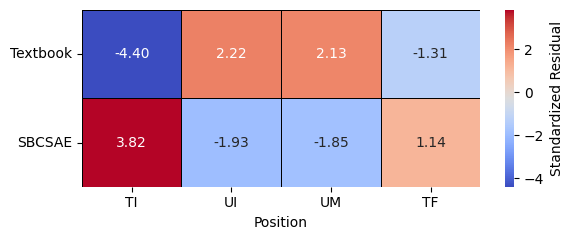

In [49]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Perform Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_df)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of freedom: {dof}")

# Calculate standardized residuals
# Add a small epsilon to expected to avoid division by zero
expected_adjusted = np.where(expected == 0, 1e-10, expected)
standardized_residuals = (contingency_df.values - expected) / np.sqrt(expected_adjusted)

# Create a DataFrame for standardized residuals for plotting
standardized_residuals_df = pd.DataFrame(standardized_residuals, index=contingency_df.index, columns=contingency_df.columns)

# Rename the columns for the heatmap labels as requested
standardized_residuals_df.columns = ['Textbook', 'SBCSAE']
display(standardized_residuals_df)

# Reorder the rows to place 'TF' at the end
# Get current index order
current_order = standardized_residuals_df.index.tolist()
# Remove 'TF' if it exists
if 'TF' in current_order:
    current_order.remove('TF')
    current_order.append('TF') # Add 'TF' to the end

standardized_residuals_df = standardized_residuals_df.loc[current_order]
display(standardized_residuals_df)

# Plotting the heatmap of standardized residuals
plt.figure(figsize=(6, 2.5)) # Reduced height further
sns.heatmap(
    standardized_residuals_df.T, # Transpose for swapping axes
    annot=True,  # Show the values on the heatmap
    cmap='coolwarm',  # Diverging colormap
    fmt=".2f",   # Format annotation to two decimal places
    linewidths=.5, # Lines between cells
    linecolor='black', # Line color
    cbar_kws={'label': 'Standardized Residual'}
)

# Removed title as requested
plt.xlabel('Position') # Swapped from 'Data Source'
# Removed plt.ylabel('Data Source') as requested
plt.yticks(rotation=0) # Explicitly set y-tick labels to be horizontal
plt.tight_layout()

# Save the heatmap to a file for download
plt.savefig('standardized_residuals_heatmap.png')
plt.show()

In [21]:
import pandas as pd

# GitHub CSV 파일 URL 목록
github_urls = [
    'https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_47.csv',
    'https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_49.csv',
    'https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_50.csv',
    'https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_51.csv',
    'https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_56.csv'
]

# Initialize an empty list to store filtered position tables from each file
all_filtered_position_tables = []

for url in github_urls:
    print(f"\n--- Processing file from URL: {url} ---")
    try:
        df = pd.read_csv(url)

        if 'position2' in df.columns:
            df['position2'] = df['position2'].astype(str).str.strip()
            position_counts = df['position2'].value_counts().sort_index()

            position_table = position_counts.reset_index()
            position_table.columns = ['Position', 'Frequency']

            # Filter out 'nan' and 'false' and other unwanted values
            filtered_position_table = position_table[~position_table['Position'].isin(['nan', 'false', 'False'])].copy()

            # Recalculate Percentage based on the filtered data for individual file (optional, but good for consistency)
            total_filtered_count_individual = filtered_position_table['Frequency'].sum()
            if total_filtered_count_individual > 0:
                filtered_position_table['Percentage'] = (filtered_position_table['Frequency'] / total_filtered_count_individual * 100).round(2)
            else:
                filtered_position_table['Percentage'] = 0.0

            print("position2 Frequency and Percentage (excluding 'nan' and 'false') for this file:")
            display(filtered_position_table)

            all_filtered_position_tables.append(filtered_position_table)
        else:
            print("'position2' column not found in this file.")
    except Exception as e:
        print(f"Error reading or processing {url}: {e}")

# Combine all filtered position tables
if all_filtered_position_tables:
    combined_df = pd.concat(all_filtered_position_tables, ignore_index=True)

    # Group by Position and sum the Frequencies
    final_summary_table = combined_df.groupby('Position')['Frequency'].sum().reset_index()

    # Exclude 'FALSE' from the combined summary table as requested
    final_summary_table = final_summary_table[final_summary_table['Position'] != 'FALSE'].copy()

    # Recalculate Percentage for the combined data (after excluding 'FALSE')
    total_combined_frequency = final_summary_table['Frequency'].sum()
    if total_combined_frequency > 0:
        # Calculate raw percentages
        final_summary_table['Percentage'] = (final_summary_table['Frequency'] / total_combined_frequency * 100)
        # Round to 2 decimal places
        final_summary_table['Percentage'] = final_summary_table['Percentage'].round(2)

        # Adjust the sum to be exactly 100% to handle floating point inaccuracies
        sum_of_percentages = final_summary_table['Percentage'].sum()
        difference = 100.00 - sum_of_percentages

        if difference != 0:
            # Find the row with the largest percentage to adjust
            # This approach minimizes the relative change for any single category
            largest_percentage_idx = final_summary_table['Percentage'].idxmax()
            final_summary_table.loc[largest_percentage_idx, 'Percentage'] += difference

    else:
        final_summary_table['Percentage'] = 0.0

    # Add a 'Total' row
    total_row = pd.DataFrame([['Total', total_combined_frequency, 100.00]], columns=final_summary_table.columns)
    final_summary_table = pd.concat([final_summary_table, total_row], ignore_index=True)

    print("\n--- Combined Summary of position2 Frequency and Percentage (excluding 'nan', 'false', and 'FALSE') ---")
    display(final_summary_table)
else:
    print("No data found for 'position2' across any of the provided URLs to generate a combined summary.")


--- Processing file from URL: https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_47.csv ---
position2 Frequency and Percentage (excluding 'nan' and 'false') for this file:


,Position,Frequency,Percentage
0,TI,21,55.26
1,UI,17,44.74



--- Processing file from URL: https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_49.csv ---
position2 Frequency and Percentage (excluding 'nan' and 'false') for this file:


,Position,Frequency,Percentage
0,TI,18,46.15
1,UI,21,53.85



--- Processing file from URL: https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_50.csv ---
position2 Frequency and Percentage (excluding 'nan' and 'false') for this file:


...

,Position,Frequency,Percentage
0,FALSE,1,2.0
1,TF,2,4.0
2,TI,11,22.0
3,UI,36,72.0



--- Processing file from URL: https://raw.githubusercontent.com/sundaybest3/txtanalysis/refs/heads/refineddata/cleaned_sbcase_56.csv ---
position2 Frequency and Percentage (excluding 'nan' and 'false') for this file:


,Position,Frequency,Percentage
0,TI,13,23.21
1,UI,41,73.21
2,UM,2,3.57



--- Combined Summary of position2 Frequency and Percentage (excluding 'nan', 'false', and 'FALSE') ---


,Position,Frequency,Percentage
0,TF,4,1.95
1,TI,75,36.59
2,UI,124,60.48
3,UM,2,0.98
4,Total,205,100.00
